In [1]:
pip install biopython

Note: you may need to restart the kernel to use updated packages.


Ejercicio 3.1 Dot-Plot y filtros

a) cree una matriz de ceros (de dimensión de acuerdo a las longitudes de seq1 y se2) y luego recorra todas las casillas poniendo 1 donde hay un match y 0 donde hay mismatch (consejo pruebe con una matriz más pequeña y luego vaya por la  completa).

b) Arme un modulo para graficar el dot-plot.

c) Programe un filtro que -opere sobre el dot-plot obtenido (el window-size “w” debería ser una variable a modificar), y reanalice los resultados. Hay varias alternativas para programar el filtro, como ser relacionadas con si las ventanas se encuentran superpuestas o son adyacentes, y si el dotplot es reemplazado por el dotplot de las ventanas y/o las mismas son solo utilizadas como filtro. Ademas se puede setear el umbral (vea el grafico para mayor claridad). Programe y compare las diferentes opciones.

In [2]:
from Bio import Entrez, SeqIO
Entrez.email = "solernadina@gmail.com"
ids = ["NP_000509.1", "NP_000518.1"]

records = []

for seq_id in ids:
    try:
        handle = Entrez.efetch(db="protein", id=seq_id, rettype="fasta", retmode="text")
        record = SeqIO.read(handle, "fasta")
        records.append(record)
        handle.close()
    except Exception as e:
        print(f"Error con {seq_id}: {e}")

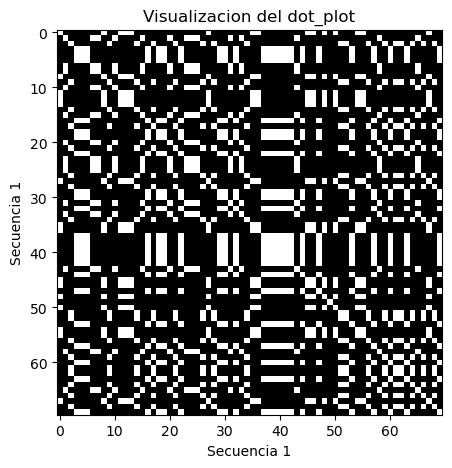

In [66]:
import numpy as np
from Bio.Seq import Seq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Me quedo solo con la secuencia que es lo que me interesa
#seq1 = records[0].seq
#seq2 = records[1].seq

seq1 = "TCGAAACCTGCTTTGCAGAACGACCCGTGAACACGTTAAAAAACATTATRTGGATTGACGAGGAGCGTGA"
seq2 = "GCTCTTAATCATCCATTGTCGGGTCATGGGATYGACCATGGTTGATCTTATGCTCTCGTACAAACACAAA"
def generar_dotplot(seq1, seq2, tipo="nucleotido", matriz=None):
    seq1, seq2 = str(seq1), str(seq2)
    dot_plot = np.zeros((len(seq1), len(seq2)))

    for i, a1 in enumerate(seq1):
        for j, a2 in enumerate(seq2):
            if tipo == "nucleotido":
                dot_plot[i, j] = 1 if a1 == a2 else 0
            elif tipo == "aminoacido":
                if matriz is None:
                    raise ValueError("Debes pasar una matriz de sustitución (ej. BLOSUM60)")
                if a1 in matriz.index and a2 in matriz.columns:
                    dot_plot[i, j] = matriz.loc[a1, a2]
                else:
                    dot_plot[i, j] = 0  # por si hay caracteres no estándar
            else:
                raise ValueError("El parámetro 'tipo' debe ser 'nucleotido' o 'aminoacido'")
    return dot_plot

dotplot = generar_dotplot(seq1,seq1, "nucleotido")
plt.figure(figsize=(10,5))
plt.imshow(dotplot, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.xlabel("Secuencia 1")
plt.ylabel("Secuencia 1")
plt.title("Visualizacion del dot_plot")
plt.show()



Para programar el filtro tenemos 2 opciones. Usar convolucion sobre la imagen, o programarlo manualmente

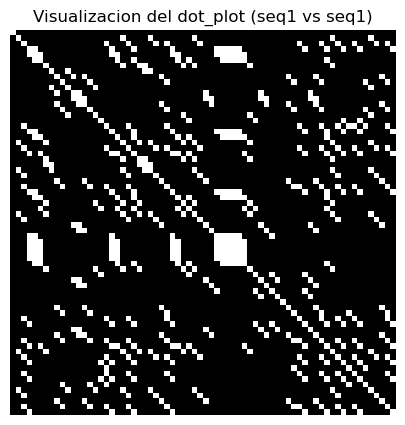

In [67]:
#Usando la libreria
from scipy import ndimage

def filtro_solapado(imagen):
    # Kernel solo vecinos permitidos (quita sup. derecha [0,2] y inf. izq [2,0])
    kernel_validos = np.array([[1,0,0],
                               [0,0,0],
                               [0,0,1]], dtype=np.uint8)

    # Conteo de vecinos
    vecinos_validos = ndimage.convolve(imagen, kernel_validos, mode="constant", cval=0)

    resultado = np.where((imagen == 1) & (vecinos_validos > 0), 1, 0)
    return resultado

imagen_filtrada = filtro_solapado(dotplot)

plt.figure(figsize=(10,5))
plt.imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1, interpolation='nearest')
plt.title("Visualizacion del dot_plot (seq1 vs seq1)")
plt.axis("off")
plt.show()

(-0.5, 69.5, 69.5, -0.5)

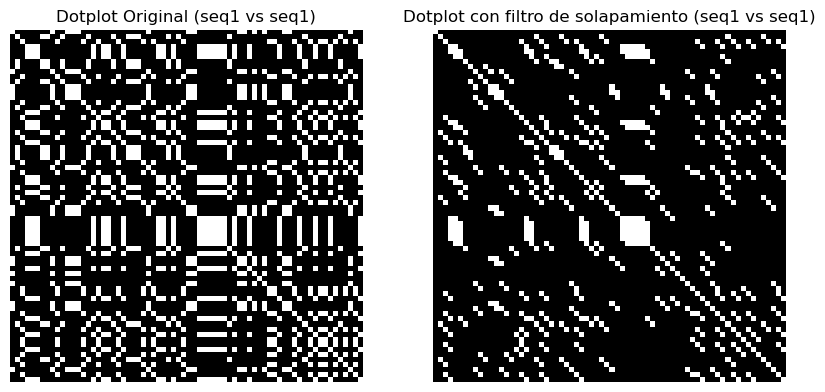

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(dotplot, cmap='gray', clim=(0,1))
axs[0].set_title("Dotplot Original (seq1 vs seq1)")
axs[0].axis("off")

axs[1].imshow(imagen_filtrada, cmap='gray', clim=(0,1))
axs[1].set_title("Dotplot con filtro de solapamiento (seq1 vs seq1)")
axs[1].axis("off")


Vemos que el filtro funciona. Hagamos otro para ver si obtenemos distintas imagenes

In [6]:
def filtro_reduccion(imagen):
    filas, columnas = imagen.shape[0],  imagen.shape[1]

    # dimensiones reducidas
    cant_filas = filas // 2 if filas % 2 == 0 else (filas - 1) // 2
    cant_columnas = columnas // 2 if columnas % 2 == 0 else (columnas - 1) // 2

    objetivo = np.array([[1,0],
                         [0,1]], dtype=np.uint8)

    imagen_filtrada = np.zeros((cant_filas, cant_columnas), dtype=np.uint8)

    for i in range(0, filas - 1, 2):
        for j in range(0, columnas - 1, 2):
            ventana = imagen[i:i+2, j:j+2]
            imagen_filtrada[i//2, j//2] = 1 if np.array_equal(objetivo, ventana) else 0

    return imagen_filtrada


(-0.5, 34.5, 34.5, -0.5)

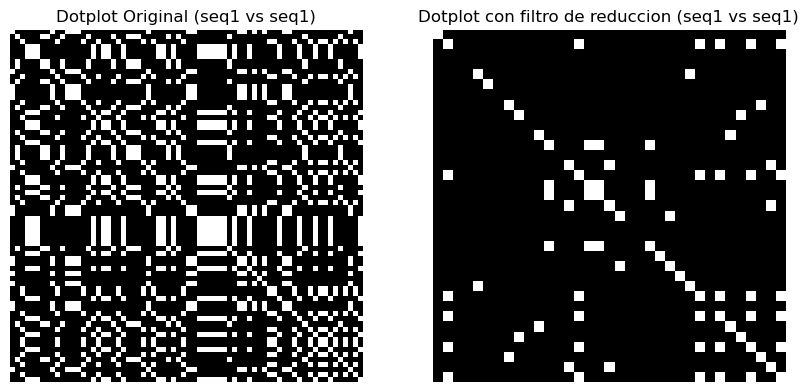

In [19]:
dotplot_filtrado = filtro_reduccion(dotplot)
fig, axs = plt.subplots(1, 2, figsize=(10, 10))

axs[0].imshow(dotplot, cmap='gray', clim=(0,1))
axs[0].set_title("Dotplot Original (seq1 vs seq1)")
axs[0].axis("off")

axs[1].imshow(dotplot_filtrado, cmap='gray', clim=(0,1))
axs[1].set_title("Dotplot con filtro de reduccion (seq1 vs seq1)")
axs[1].axis("off")


El siguiente algoritmo consigue un alineamiento global. Por lo que considera que la solucion empieza en la posicion (0,0) y en una matriz de nxn, el camino mas optimo terminara en la celda (n,n)

[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  1  1  1]
 [ 0  0  1 ...  2  2  2]
 ...
 [ 0  1  2 ... 39 39 39]
 [ 0  1  2 ... 39 39 39]
 [ 0  1  2 ... 40 40 40]]


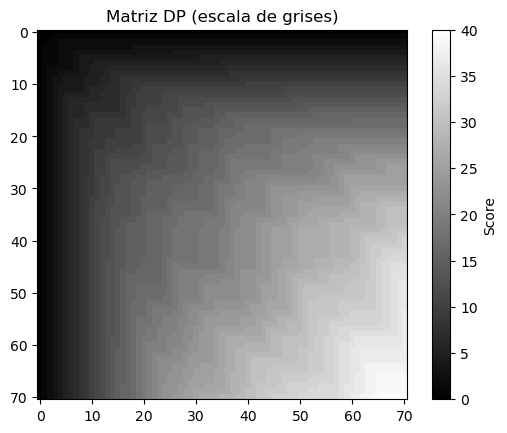

In [8]:
def puntaje_acum(s1, s2):
    n, m = len(s1), len(s2)
    dp = np.zeros((n+1, m+1), dtype=int)
    for i in range(1, n+1):
        for j in range(1, m+1):
            if s1[i-1] == s2[j-1]:
                dp[i,j] = dp[i-1, j-1] + 1
            else:
                dp[i,j] = max(dp[i-1, j],dp[i, j-1], dp[i-1, j-1])
    return dp

print(puntaje_acum(seq1,seq2))
matriz_puntaje_acum = puntaje_acum(seq1,seq2)

plt.imshow(matriz_puntaje_acum, cmap="gray", origin="upper")
plt.colorbar(label="Score")
plt.title("Matriz DP (escala de grises)")
plt.show()


Con la funcion de arriba podemos ver donde se obtiene el maximo alineamiento (aca que no penalizamos con numeros negativos seguro que va a andar por la esquina inferior derecha, pero si sumamos penalidad por gaps, podriamos tener que el mejor alineamiento no estaria por ahi. Es por eso que cuando reconstruye el camino, le pasamos la celda desde donde tiene que reconstruir. Aca lo hacemos manualmente pidiendolo, pero si quisieramos podriamos pedir que arranque desde el puntaje maximo para automatizarlo)

In [9]:
def camino_dotplot(seq1, seq2):
    n, m = len(seq1), len(seq2)
    # Matriz de dotplot (ponemos columna y filas de ceros al principio para tener los casos bases cubiertos)
    dp = np.zeros((n+1, m+1), dtype=int)
    # registramos las coordenadas
    coords = np.zeros((n+1, m+1), dtype=tuple)

    # en cada celda guardamos de donde viene el mejor puntaje
    # consideremos que pusimos una primer fila y primer columna de ceros. para que pueda hacer el primer caso
    for i in range(1, n+1):
        for j in range(1, m+1):
            # vemos de donde viene el mejor puntaje
            # como dp tiene una columna y filas mas de ceros. la posicion (k,k) en la matriz, es el elemento k-1 en la secuencia
            match = dp[i-1, j-1] + (1 if seq1[i-1] == seq2[j-1] else 0) + 4
            up = dp[i-1, j]
            left = dp[i, j-1]
            dp[i, j] = max(match, up, left)

            # guardamos las coordenadas de donde vino el mejor puntaje en la celda actual
            if dp[i, j] == match:
                coords[i, j] = (i-1, j-1)
            elif dp[i, j] == up:
                coords[i, j] = (i-1, j)
            else:
                coords[i, j] = (i, j-1)

    return coords

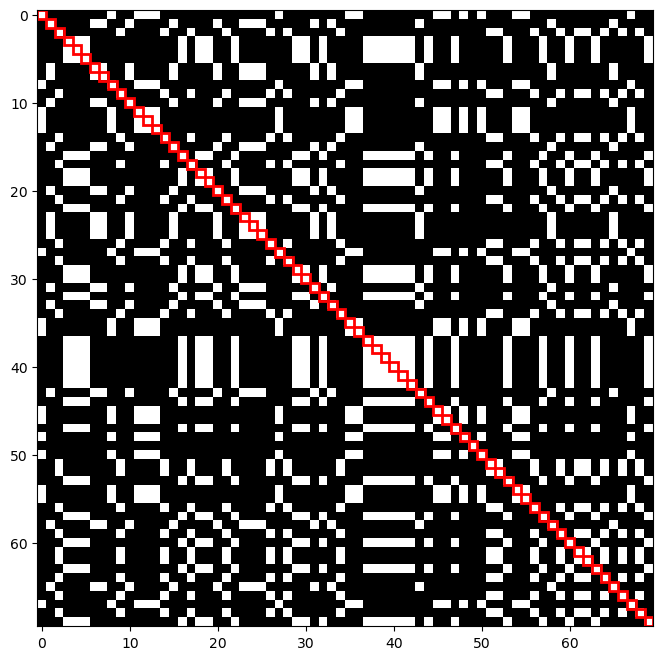

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def dibujar_camino(dotplot, backtrack, start=None, ax=None):
    n, m = dotplot.shape

    # Si no me pasan ax, creo uno nuevo
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Dibujo el dotplot (0/1)
    ax.imshow(dotplot, cmap=plt.cm.colors.ListedColormap(["black", "white"]), origin="upper")

    # Empiezo desde la esquina inferior derecha si no me pasan start
    if start is None:
        i, j = n-1, m-1
    else:
        i, j = start

    # Trazo el camino hacia atrás
    while True:
        rect = patches.Rectangle((j-0.5, i-0.5), 1, 1,
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)

        if not isinstance(backtrack[i, j], tuple):
            break
        i, j = backtrack[i, j]

        if i == 0 and j == 0:
            rect = patches.Rectangle((j-0.5, i-0.5), 1, 1,
                                     linewidth=2, edgecolor='red', facecolor='none')
            ax.add_patch(rect)
            break

    return ax

coords = camino_dotplot(seq1, seq2)
# Supongamos que ya tenés dotplot y backtrack definidos
ax = dibujar_camino(dotplot, coords)

# Mostrar la figura
plt.show()



Veamos todo junto para poder comparar bien

-----------------------ANALISIS PARA SECUENCIA 1 VS SECUENCIA 1-----------------------


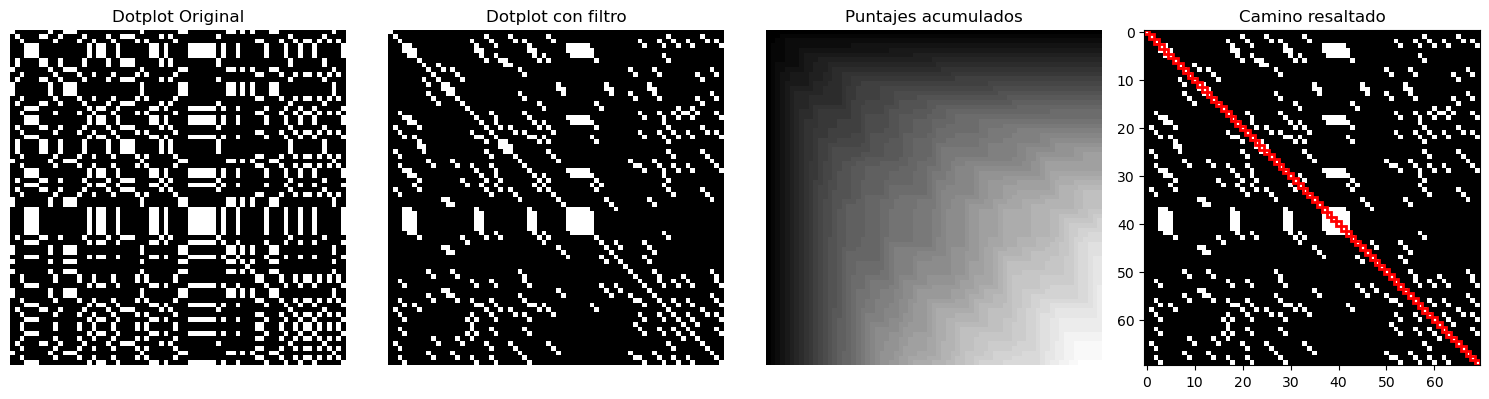

In [25]:
imagen_filtrada = filtro_solapado(dotplot)

print("-----------------------ANALISIS PARA SECUENCIA 1 VS SECUENCIA 1-----------------------")

fig, axs = plt.subplots(1, 4, figsize=(15, 10))

# Dotplot Original
axs[0].imshow(dotplot, cmap='gray', vmin=0, vmax=1)
axs[0].set_title("Dotplot Original")
axs[0].axis("off")

# Dotplot Filtrado
axs[1].imshow(imagen_filtrada, cmap='gray', vmin=0, vmax=1)
axs[1].set_title("Dotplot con filtro")
axs[1].axis("off")

# Puntajes acumulados
axs[2].imshow(matriz_puntaje_acum, cmap='gray')
axs[2].set_title("Puntajes acumulados")
axs[2].axis("off")

# Camino resaltado en el cuarto subplot
dibujar_camino(imagen_filtrada, coords, ax=axs[3])
axs[3].set_title("Camino resaltado")

plt.tight_layout()
plt.show()


In [57]:
secuencia1 = "ACGTTCAGTAG"
secuencia2 = "ACCACTTG"

def puntaje_acum_blosum(s1, s2, blosum):
    n, m = len(s1), len(s2)
    dp = np.zeros((n+1, m+1), dtype=int)

    for i in range(1, n+1):
        for j in range(1, m+1):
            aa1 = s1[i-1]
            aa2 = s2[j-1]

            try:
                score_sub = blosum.loc[aa1, aa2]
            except KeyError:
                # Si uno de los aminoácidos no está en la matriz, usar score neutro
                score_sub = -1

            # Puntajes posibles:
            # - reemplazo (diagonal)
            # - eliminación (arriba)
            # - inserción (izquierda)
            dp[i, j] = max(
                dp[i-1, j-1] + score_sub,  # reemplazo o coincidencia
                dp[i-1, j],                # eliminación
                dp[i, j-1]                 # inserción
            )

    return dp

def max_matriz(matriz):
    max_valor = matriz[0][0]
    posicion = (0, 0)
    for i, fila in enumerate(matriz):
        for j, elem in enumerate(fila):
            if elem > max_valor:
                max_valor = elem
                posicion = (i, j)
    return posicion

def seguir_por(seq1, seq2, matriz, fila_inicial, columna_inicial):
    diagonal = matriz[fila_inicial - 1][columna_inicial - 1]
    horizontal = matriz[fila_inicial][columna_inicial - 1]
    vertical = matriz[fila_inicial - 1][columna_inicial]
    maximo = max(diagonal, horizontal, vertical)

    if maximo == diagonal and seq1[fila_inicial - 1] == seq2[columna_inicial - 1]:
        return "d,m"
    elif maximo == diagonal:
        return "d,mm"
    elif maximo == vertical:
        return "vertical"
    else:
        return "horizontal"

def posicion_es_diagonal(fila, columna):
    return fila == columna

def son_iguales(letra1, letra2):
    return letra1 == letra2

def mostrar_alineamiento(seq1, seq2, tipo="nucleotidos"):
    # Elegir la función de puntaje según el tipo
    if tipo.lower() == "nucleotidos":
        matriz_puntaje = puntaje_acum(seq1, seq2)
    else:
        matriz_puntaje = puntaje_acum_blosum(seq1, seq2, blosum60_df)

    f, c = max_matriz(matriz_puntaje)

    alineamiento1, alineamiento2, alineamiento3 = [], [], []

    while f > 0 and c > 0:
        siguiente = seguir_por(seq1, seq2, matriz_puntaje, f, c)

        if siguiente == "d,m":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            alineamiento3.append("*")
            f, c = f-1, c-1
        elif siguiente == "d,mm":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append(seq2[c-1])
            alineamiento3.append(" ")
            f, c = f-1, c-1
        elif siguiente == "vertical":
            alineamiento1.append(seq1[f-1])
            alineamiento2.append("-")
            alineamiento3.append(" ")
            f = f-1
        elif siguiente == "horizontal":
            alineamiento1.append("-")
            alineamiento2.append(seq2[c-1])
            alineamiento3.append(" ")
            c = c-1

    print("".join(reversed(alineamiento1)))
    print("".join(reversed(alineamiento2)))
    print("".join(reversed(alineamiento3)))


mostrar_alineamiento(secuencia1, secuencia2, "nucleotidos")
mostrar_alineamiento(seq1, seq2, "nucleotidos")



ACGTTCAGTAG
AC---CACTTG
**   ** * *
TC-GAA--A-CC-T-G-C---TTTGCA-GAACG-ACCCGT-GAAC-ACG-TT-AAAAAACATTATRTGGAT-T-G-ACGAGGAGCGTGA
TCTTAATCATCCATTGTCGGGT---CATG---GGA----TYGA-CCATGGTTGA----TC-TTAT--G-CTCTCGTAC-A--AAC---A
**  **  * ** * * *   *   ** *   * *    * ** * * * ** *     * ****  *  * * * ** *  * *   *


# Alineamiento de proteinas de a pares

Cargamos la matriz blosum60, y realizamos un grafico de distribuciones

In [30]:
import pandas as pd

def cargar_blosum60(path="blosum60.txt"):
    with open(path) as f:
        lines = [line.strip() for line in f if not line.startswith("#")]

    header = lines[0].split()
    data = []
    index = []

    for line in lines[1:]:
        parts = line.split()
        index.append(parts[0])
        data.append([int(x) for x in parts[1:]])

    df = pd.DataFrame(data, index=index, columns=header)
    return df

# Cargar matriz
blosum60_df = cargar_blosum60()

# Mostrar parte de la matriz
print(blosum60_df)


   A  R  N  D  C  Q  E  G  H  I  L  K  M  F  P  S  T   W  Y  V
A  5 -2 -1 -2 -1 -1 -1  0 -2 -2 -2 -1 -1 -3 -1  1  0  -4 -2  0
R -2  6  0 -2 -4  1 -1 -3  0 -3 -3  2 -2 -3 -2 -1 -1  -3 -1 -3
N -1  0  6  1 -3  0  0 -1  1 -3 -4  0 -2 -4 -2  1  0  -4 -2 -3
D -2 -2  1  6 -4  0  2 -1 -1 -4 -5 -1 -4 -4 -1  0 -1  -6 -4 -4
C -1 -4 -3 -4  9 -4 -5 -3 -4 -2 -2 -4 -2 -3 -4 -1 -1  -3 -3 -1
Q -1  1  0  0 -4  6  2 -2  2 -3 -2  1  0 -4 -1 -1 -1  -2 -1 -3
E -1 -1  0  2 -5  2  6 -3  0 -4 -3  1 -2 -4 -1 -1 -1  -3 -2 -3
G  0 -3 -1 -1 -3 -2 -3  6 -2 -5 -4 -2 -3 -4 -2  0 -2  -3 -3 -4
H -2  0  1 -1 -4  2  0 -2  7 -3 -2 -1 -2 -2 -2 -1 -2  -2  2 -3
I -2 -3 -3 -4 -2 -3 -4 -5 -3  5  2 -3  2  1 -4 -3 -1  -3 -1  4
L -2 -3 -4 -5 -2 -2 -3 -4 -2  2  5 -3  3  2 -4 -3 -2  -2 -1  1
K -1  2  0 -1 -4  1  1 -2 -1 -3 -3  5 -2 -4 -1  0 -1  -3 -2 -3
M -1 -2 -2 -4 -2  0 -2 -3 -2  2  3 -2  7  0 -3 -2 -1  -1 -1  1
F -3 -3 -4 -4 -3 -4 -4 -4 -2  1  2 -4  0  8 -4 -3 -3   1  4 -1
P -1 -2 -2 -1 -4 -1 -1 -2 -2 -4 -4 -1 -3 -4  8 -1 -2  -

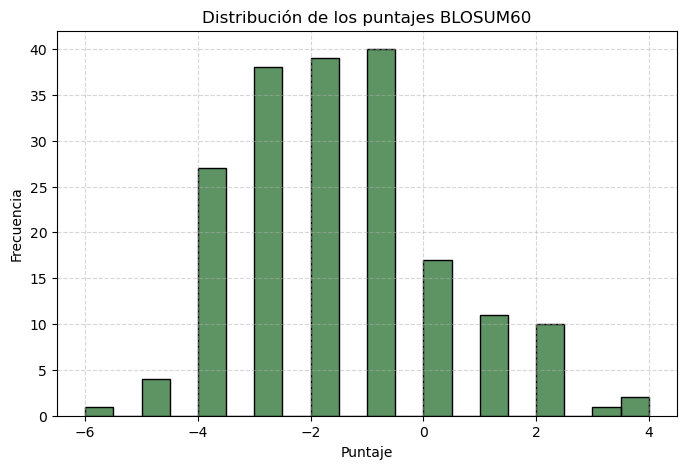

In [49]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matrix = blosum60_df.values

values = matrix[np.triu_indices_from(matrix, k=1)]

# --- Graficar ---
plt.figure(figsize=(8,5))
sns.histplot(values, bins=20, color= "#287030")

plt.title("Distribución de los puntajes BLOSUM60")
plt.xlabel("Puntaje")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


La matriz blosum60 tolera bastantes sustituciones de aminoacidos, ya que su porcentaje de identidad entre secuencias es ≥60%. Entonces, si aun así un par de aminoácidos recibe un puntaje negativo, quiere decir que esa sustitución es muy poco probable incluso considerando divergencia (es una penalización más fuerte). Es por esto, que decidimos establecer un umbral de corte de la siguiente manera:
* 1 si dotplot[i,j] ≥ -1
* 0 si dotplot[i,j] < 1

Realizamos una funcion que nos permita filtrar nuestro dot plot de aminoacidos.

    filtrar_dotplot_aminoacidos.

    Parámetros:
    -----------
    matrix : np.ndarray o pd.DataFrame
        Matriz de similitud/puntajes.
    umbral : int o float
        Valor del umbral.
    modo : str, "binario" o "filtrado"
        - "binario": los valores >= umbral → 1, si no → 0
        - "filtrado": los valores >= umbral se conservan, si no → 0

    Retorna:
    --------
    np.ndarray con los valores filtrados

In [50]:
import numpy as np

def filtrar_dotplot_aminoacidos(matrix, umbral, modo="binario"):
    arr = matrix.values if hasattr(matrix, "values") else np.array(matrix)

    if modo == "binario":
        return (arr >= umbral).astype(int)
    elif modo == "filtrado":
        return np.where(arr >= umbral, arr, 0)
    else:
        raise ValueError("El modo debe ser 'binario' o 'filtrado'")


ejemplo de como usarla

[[ 0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1]
 [ 0  0  0  0  0  0  1  1  1  1  1  1  1  1  1  1  1  1  1  1 10]
 [ 0  0  0  0  0  0  1  1  1  1  2  2  2  2  2  2  2  2  3  7 10]
 [ 0  0  0  0  0  0  1  1  3  3  3  3  3  3  3  3  3  3  8  8 10]
 [ 0  4  4  8  8  8  8  8  8  8  8  8  8  8  8  8  8 11 11 11 11]
 [ 0  4  4  8  8  8  8  8  8  8  8  8  8  8  8  8 14 14 14 14 14]
 [ 0  4  4  8  8  8  8  8 10 10 10 10 10 10 10 15 15 15 15 15 15]
 [ 0  4  4  8 12 12 12 12 12 12 12 12 12 12 15 15 15 16 16 16 16]
 [ 0  4  4  8 12 12 12 14 14 14 14 14 14 17 17 17 17 17 17 17 17]
 [ 0  4  4  8 12 12 12 14 14 14 14 17 19 19 19 19 19 19 19 19 19]
 [ 0  4  4  8 12 12 12 14 14 14 14 21 21 21 21 21 21 21 21 21 21]
 [ 0  4  4  8 12 12 13 14 14 14 20 21 21 21 21 22 22 22 22 22 22]
 [ 0  4  4  8 12 12 13 14 14 22 22 22 22 22 22 22 22 22 22 22 22]
 [ 0  4  4  8 12 12 13 14 20 22 22 22 22 23 23 24 24 24 24 24 24]
 [ 0  4  4

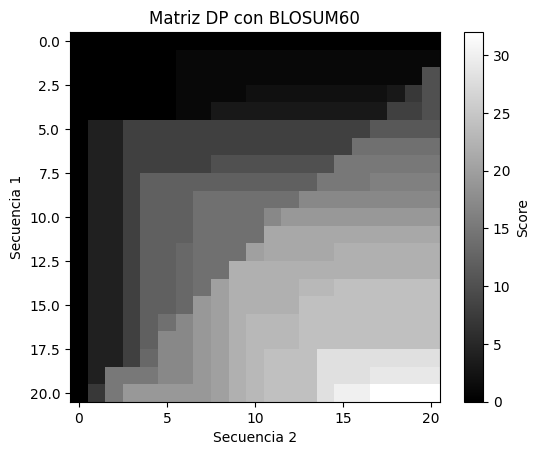

In [ ]:

seq1 = "ACDEFGHIKLMNPQRSTVWY"
seq2 = "YWFVTSRQPNMLKIHGFEDC"

matriz_puntaje = puntaje_acum_blosum(seq1, seq2, blosum60_df)

print(matriz_puntaje)

plt.imshow(matriz_puntaje, cmap="gray", origin="upper")
plt.colorbar(label="Score")
plt.title("Matriz DP con BLOSUM60")
plt.xlabel("Secuencia 2")
plt.ylabel("Secuencia 1")
plt.show()

    Calcula el mejor camino de alineamiento usando programación dinámica.
    
    Parámetros
    ----------
    dotplot : np.ndarray
        Matriz de puntajes (ej: salida de generar_dotplot filtrado).
    gap_penalty : int o float
        Penalización por gap.

    Retorna
    -------
    score_matrix : np.ndarray
        Matriz de puntuaciones.
    traceback : list of tuple
        Camino óptimo (lista de coordenadas).


In [52]:
import numpy as np

def alinear_dotplot(dotplot, gap_penalty=-1):
    n_rows, n_cols = dotplot.shape
    score = np.zeros((n_rows+1, n_cols+1))
    traceback = np.zeros((n_rows+1, n_cols+1), dtype="object")

    # Inicialización (alineamiento global → penalización en bordes)
    for i in range(1, n_rows+1):
        score[i, 0] = i * gap_penalty
        traceback[i, 0] = (i-1, 0)
    for j in range(1, n_cols+1):
        score[0, j] = j * gap_penalty
        traceback[0, j] = (0, j-1)

    # Rellenar matriz de scores
    for i in range(1, n_rows+1):
        for j in range(1, n_cols+1):
            match = score[i-1, j-1] + dotplot[i-1, j-1]
            delete = score[i-1, j] + gap_penalty
            insert = score[i, j-1] + gap_penalty
            best = max(match, delete, insert)
            score[i, j] = best

            # guardar traceback
            if best == match:
                traceback[i, j] = (i-1, j-1)
            elif best == delete:
                traceback[i, j] = (i-1, j)
            else:
                traceback[i, j] = (i, j-1)

    # Reconstrucción del camino
    path = []
    i, j = n_rows, n_cols
    while (i, j) != (0, 0):
        path.append((i-1, j-1))
        i, j = traceback[i, j]
    path.reverse()

    return score, path


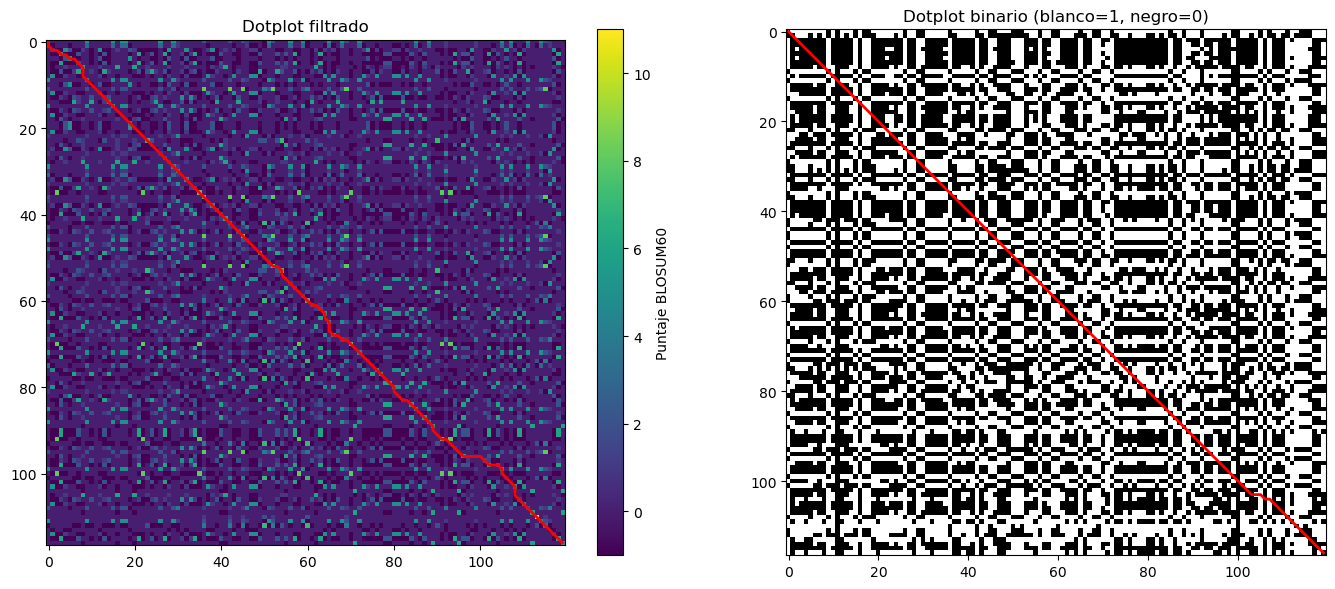

In [73]:
# testeando con secuencias grandes
hemO = "LMSETENQALTFAKRLKADTTAVHDSVDNLVMSVQPFVSKENYIKFLKLQSVFHKAVDHIYKDAELNKAIPELEYMARYDAVTQDLKDLGEEPYKFDKELPYEAGNKAIGWLYCAEG"
coincidencia_blast = "LAPESTRQNLR-SQRLNLLTNEPHQRLESLVKSKEPFASRDNFARFVAAQYLFQHDLEPLYRNEALARLFPGLASRARDDAARADLADLGHPVPEGDQSV-READLSLAEALGWLFVSEG"
umbral = -1

dotplot_aa = generar_dotplot(hemO, coincidencia_blast, tipo="aminoacido", matriz=blosum60_df)
filtrado = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="filtrado")
filtrado_binario = filtrar_dotplot_aminoacidos(dotplot_aa, umbral, modo="binario")


_, path0 = alinear_dotplot(filtrado, gap_penalty=-1)
_, path1 = alinear_dotplot(filtrado_binario, gap_penalty=-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Dotplot filtrado normal con viridis
im0 = axes[0].imshow(filtrado, cmap="viridis", interpolation="nearest")
y0, x0 = zip(*path0)
axes[0].plot(x0, y0, color="red", linewidth=2)
axes[0].set_title("Dotplot filtrado")
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label("Puntaje BLOSUM60")

# Dotplot binario en blanco y negro
axes[1].imshow(filtrado_binario, cmap="gray_r", interpolation="nearest")
y1, x1 = zip(*path1)
axes[1].plot(x1, y1, color="red", linewidth=2)
axes[1].set_title("Dotplot binario (blanco=1, negro=0)")

plt.tight_layout()
plt.show()



In [74]:
mostrar_alineamiento(hemO, coincidencia_blast, "aminoacidos")

LMS-ET--ENQALTFAKR----LKAD--TTAVH------DSVDNLVMSVQ-PFVS-KENYIKF---L--KLQSVF--H-KAVDHIYKDAE-L--NKA---I-PELEYMA-R-YD-AVTQ-DLKDLGEEP-YKFD--K----E--L-PYEA-GNKAIGWLYCAEG
L-APESTRQN--L---R--SQRL--NLLT---NEPHQRLESL---VKS-KEPF-ASRDNF---ARFVAAQ----YLFQH---D-L-E---PLYRNEALARLFPGL---ASRARDDA-ARADLADLG-HPVPE--GDQSV-READLSLAEALG-----WLFVSEG
*   *    *  *         *     *           *    * *   **     *                       *        *  * *     * *   * *  * *    ** ***  *            *  *   ** *     **   **


Esto fue lo obtenido por el blast

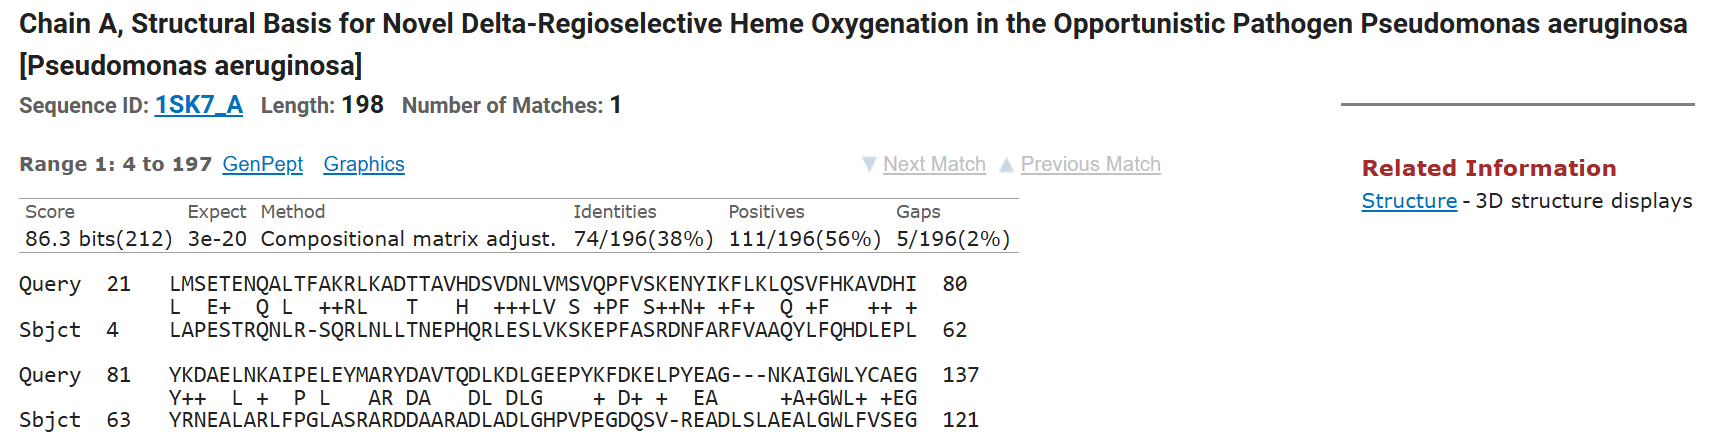

Nuestro alineamiento encuentra varios matchs, pero tambien pone muchos gaps, teniendo diferencias notorias con el alineamiento de blast.

Algunas diferencias que encontramos en internet tambien son las siguientes:
* blast utiliza otra penalizacion de gap y otra matriz de blosum, por lo que las diferencias podrian deberse a eso.
* blast prioriza un alineamiento local, mientras que nosotros estamos buscando un alineamiento global
* blast mira tambien los positives, y nosotros no